<a href="https://colab.research.google.com/github/Marfall/Clasterization-Otus-2/blob/main/Clasterization_Otus_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №2 "Кластеризация"

##1. Введение

Это домашнее задание посвящено кластеризации клиентов немецкого банка.
Мы будем использовать три популярных алгоритма: K‑means, иерархическую кластеризацию и DBSCAN.
Цель — разделить клиентов на однородные группы и дать им содержательную интерпретацию.

Данные взяты из открытого источника (German Credit Data).
Они содержат информацию о 1000 клиентах: возраст, сумма кредита, срок, цель, статус счёта и другие признаки.

In [21]:
# 2. Установка дополнительной библиотеки UMAP (она не входит в стандартный набор Colab)
!pip install -q umap-learn

print("Библиотеки установлены.")

Библиотеки установлены.


##3. Импорт необходимых библиотек

Мы загружаем стандартный набор для анализа данных:
- pandas — работа с таблицами
- numpy — математические операции
- matplotlib и seaborn — графики
- sklearn — алгоритмы кластеризации и предобработка
- scipy — для дендрограммы
- umap — для визуализации

Все импорты вынесены в одну ячейку для удобства.

In [22]:
# 4. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import umap.umap_ as umap

# Настройка внешнего вида графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("Все библиотеки загружены.")

Все библиотеки загружены.


##5. Загрузка данных

Мы ищем файл с именем german_credit_data.csv или german_credit.csv
сначала в текущей папке, потом в папке /content/.
Если файл не найден — скрипт попросит загрузить его вручную через кнопку.

In [23]:
# 6. Загрузка данных с возможностью ручной загрузки
possible_names = ['german_credit_data.csv', 'german_credit.csv']
file_path = None

# Проверяем наличие файла
for name in possible_names:
    if os.path.exists(name):
        file_path = name
        break
    if os.path.exists('/content/' + name):
        file_path = '/content/' + name
        break

# Если не нашли — просим загрузить
if file_path is None:
    print("Файл не найден в текущей папке.")
    print("Пожалуйста, загрузите файл с вашего компьютера.")
    from google.colab import files
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]
    print(f"Файл '{file_path}' загружен.")

# Читаем CSV
df_raw = pd.read_csv(file_path)
print(f"Данные загружены, форма: {df_raw.shape} (строк, столбцов)")
print("Первые 5 строк:")
display(df_raw.head())

Файл не найден в текущей папке.
Пожалуйста, загрузите файл с вашего компьютера.


Saving german_credit_data 3.csv to german_credit_data 3.csv
Файл 'german_credit_data 3.csv' загружен.
Данные загружены, форма: (1000, 10) (строк, столбцов)
Первые 5 строк:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


##7. Первичный осмотр данных (EDA)

На этом этапе мы знакомимся с таблицей:
- смотрим типы данных и количество непустых значений
- получаем описательную статистику для чисел
- проверяем наличие дубликатов

Это помогает понять, какие колонки требуют обработки.

In [24]:
# 8. EDA: информация, статистика, дубликаты
print("=== Информация о колонках ===")
df_raw.info()

print("\n=== Статистика числовых признаков ===")
display(df_raw.describe())

duplicates = df_raw.duplicated().sum()
print(f"\nКоличество полных дубликатов строк: {duplicates}")

=== Информация о колонках ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB

=== Статистика числовых признаков ===


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000



Количество полных дубликатов строк: 0


##9. Обработка пропущенных значений

В колонках Saving accounts и Checking account есть пропуски (NaN).
Вместо удаления таких строк мы заполняем их специальной меткой 'no_account'.
Это означает, что у клиента нет сберегательного или текущего счета,
либо информация отсутствует — и это само по себе важный признак.

In [25]:
# 10. Заполнение пропусков
df = df_raw.copy()  # создаём копию, чтобы не портить исходные данные
df['Saving accounts'] = df['Saving accounts'].fillna('no_account')
df['Checking account'] = df['Checking account'].fillna('no_account')

# Проверяем, что пропусков больше нет
print("Пропуски после заполнения:")
print(df.isnull().sum())

Пропуски после заполнения:
Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


##11. Преобразование категориальных признаков в числа

Алгоритмы кластеризации работают с числами, поэтому все текстовые колонки нужно закодировать.
Мы используем два подхода:
- Для порядковых категорий (Saving accounts, Checking account) — присваиваем числа, отражающие градацию (0 — нет счета, 1 — мало, 2 — умеренно, 3 — много).
- Для номинальных категорий (Purpose, Sex, Housing, Job) — применяем One-Hot Encoding, создавая отдельные колонки-флажки.

Целевую переменную Risk (если она есть) мы не используем для обучения, но сохраняем для дополнительного анализа.

In [26]:
# 12. Кодирование категорий
# Порядковые категории
saving_map = {'no_account':0, 'little':1, 'moderate':2, 'rich':3, 'quite rich':4}
df['Saving_encoded'] = df['Saving accounts'].map(saving_map)

checking_map = {'no_account':0, 'little':1, 'moderate':2, 'rich':3}
df['Checking_encoded'] = df['Checking account'].map(checking_map)

# One-Hot для номинальных категорий
categorical_cols = ['Purpose', 'Sex', 'Housing', 'Job']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Удаляем старые текстовые колонки
df_encoded = df_encoded.drop(columns=['Saving accounts', 'Checking account'])

# Отделяем целевую переменную (если есть)
if 'Risk' in df_encoded.columns:
    y_risk = df_encoded['Risk'].values  # сохраняем для анализа
    df_features = df_encoded.drop(columns=['Risk'])
else:
    y_risk = None
    df_features = df_encoded

print(f"Размер признакового пространства: {df_features.shape[1]} колонок")
print("Первые строки после кодирования:")
display(df_features.head())

Размер признакового пространства: 19 колонок
Первые строки после кодирования:


,Unnamed: 0,Age,Credit amount,Duration,Saving_encoded,Checking_encoded,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Sex_male,Housing_own,Housing_rent,Job_1,Job_2,Job_3
0,0,67,1169,6,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0
1,1,22,5951,48,1,2,0,0,0,0,1,0,0,0,1,0,0,1,0
2,2,49,2096,12,1,0,0,0,1,0,0,0,0,1,1,0,1,0,0
3,3,45,7882,42,1,1,0,0,0,1,0,0,0,1,0,0,0,1,0
4,4,53,4870,24,1,1,1,0,0,0,0,0,0,1,0,0,0,1,0


##13. Масштабирование признаков

Кластеризация основана на вычислении расстояний между точками.
Если признаки имеют разные единицы измерения (например, возраст — от 18 до 70, а сумма кредита — от 1000 до 20000),
то большие числа будут доминировать, и алгоритм фактически проигнорирует мелкие признаки.

Чтобы этого избежать, мы приводим все числовые признаки к одному масштабу
с помощью StandardScaler (вычитаем среднее и делим на стандартное отклонение).

One‑Hot признаки (0/1) мы не масштабируем, так как они уже находятся в одном диапазоне.

In [27]:
# 14. Масштабирование
# Определяем колонки, которые нужно масштабировать
cols_to_scale = ['Age', 'Credit amount', 'Duration', 'Saving_encoded', 'Checking_encoded']
# Остальные колонки (One‑Hot) оставляем без изменений
cols_not_to_scale = [col for col in df_features.columns if col not in cols_to_scale]

# Создаём объект StandardScaler и применяем его к выбранным колонкам
scaler = StandardScaler()
df_scaled_part = scaler.fit_transform(df_features[cols_to_scale])
# Превращаем результат обратно в DataFrame с сохранением индексов
df_scaled_part = pd.DataFrame(df_scaled_part, columns=cols_to_scale, index=df_features.index)

# Объединяем масштабированные колонки с немаштабируемыми
df_final = pd.concat([df_scaled_part, df_features[cols_not_to_scale]], axis=1)

print(f"Финальная матрица признаков: {df_final.shape}")
print("Пример масштабированных значений:")
display(df_final.head())

Финальная матрица признаков: (1000, 19)
Пример масштабированных значений:


,Age,Credit amount,Duration,Saving_encoded,Checking_encoded,Unnamed: 0,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Sex_male,Housing_own,Housing_rent,Job_1,Job_2,Job_3
0,2.766456,-0.745131,-1.236478,-1.203212,-0.001045,0,0,0,0,0,1,0,0,1,1,0,0,1,0
1,-1.191404,0.949817,2.248194,-0.204696,1.044372,1,0,0,0,0,1,0,0,0,1,0,0,1,0
2,1.183312,-0.416562,-0.738668,-0.204696,-1.046463,2,0,0,1,0,0,0,0,1,1,0,1,0,0
3,0.831502,1.634247,1.750384,-0.204696,-0.001045,3,0,0,0,1,0,0,0,1,0,0,0,1,0
4,1.535122,0.566664,0.256953,-0.204696,-0.001045,4,1,0,0,0,0,0,0,1,0,0,0,1,0


##15. K‑means кластеризация: подбор числа кластеров

K‑means требует заранее задать число кластеров K.
Мы будем перебирать K от 2 до 10 и для каждого значения вычислять две метрики:
- Инерция (сумма квадратов расстояний до центров) — чем меньше, тем лучше, но с ростом K она всегда падает.
- Коэффициент силуэта — показывает, насколько хорошо точки сгруппированы. Принимает значения от -1 до 1, чем ближе к 1, тем лучше.

Мы строим графики и выбираем K, при котором силуэт максимален.

Подбор K для K‑means:
  K=2: силуэт = 0.6257
  K=3: силуэт = 0.5884
  K=4: силуэт = 0.5693
  K=5: силуэт = 0.5574
  K=6: силуэт = 0.5491
  K=7: силуэт = 0.5426
  K=8: силуэт = 0.5379
  K=9: силуэт = 0.5337
  K=10: силуэт = 0.5295


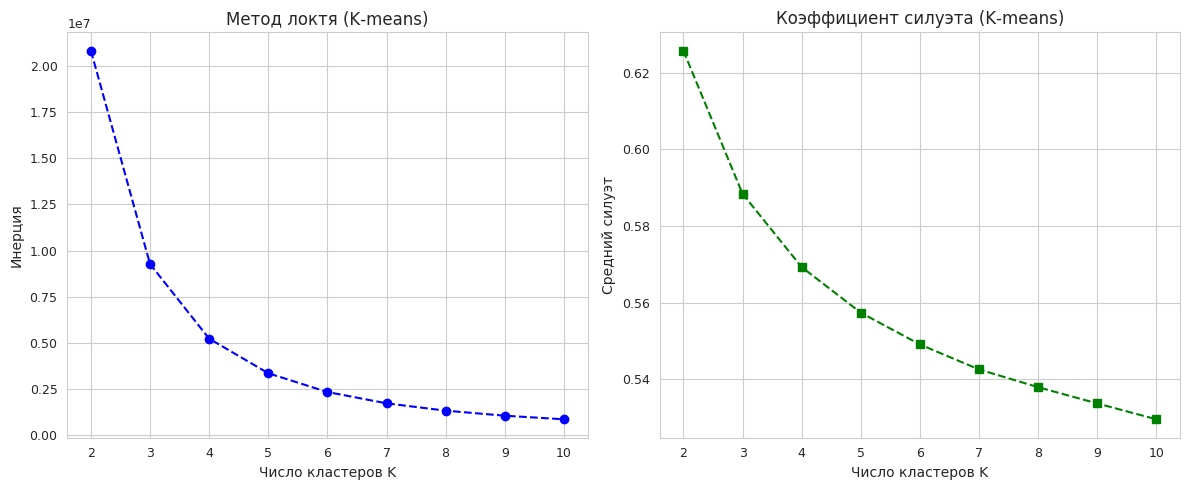

Оптимальное K для K‑means: 2
Метки кластеров для K‑means сохранены.


In [10]:
# 16. K‑means: подбор K и визуализация
range_k = range(2, 11)  # от 2 до 10
inertias = []   # список для инерции
sil_scores = [] # список для силуэта

print("Подбор K для K‑means:")
for k in range_k:
    # Создаём и обучаем модель
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_final)
    # Сохраняем инерцию и силуэт
    inertias.append(km.inertia_)
    sil = silhouette_score(df_final, km.labels_)
    sil_scores.append(sil)
    print(f"  K={k}: силуэт = {sil:.4f}")

# Рисуем два графика рядом
plt.figure(figsize=(12,5))
# Локоть
plt.subplot(1,2,1)
plt.plot(range_k, inertias, marker='o', linestyle='--', color='b')
plt.title('Метод локтя (K‑means)')
plt.xlabel('Число кластеров K')
plt.ylabel('Инерция')
plt.grid(True)
# Силуэт
plt.subplot(1,2,2)
plt.plot(range_k, sil_scores, marker='s', linestyle='--', color='g')
plt.title('Коэффициент силуэта (K‑means)')
plt.xlabel('Число кластеров K')
plt.ylabel('Средний силуэт')
plt.grid(True)
plt.tight_layout()
plt.show()

# Выбираем лучшее K по максимуму силуэта
best_k = range_k[np.argmax(sil_scores)]
print(f"Оптимальное K для K‑means: {best_k}")

# Обучаем финальную модель с лучшим K
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(df_final)
print("Метки кластеров для K‑means сохранены.")

##17. Иерархическая кластеризация (агломеративная)

Этот метод не требует заранее задавать число кластеров — он строит дерево (дендрограмму),
где каждая точка изначально является отдельным кластером, а затем попарно объединяются ближайшие.

Мы используем метод Уорда (ward), который минимизирует внутрикластерную дисперсию.

Для выбора числа кластеров мы:
- Строим дендрограмму на случайной выборке (чтобы дерево было читаемым).
- Дополнительно перебираем K от 2 до 10 и выбираем по максимуму силуэта.

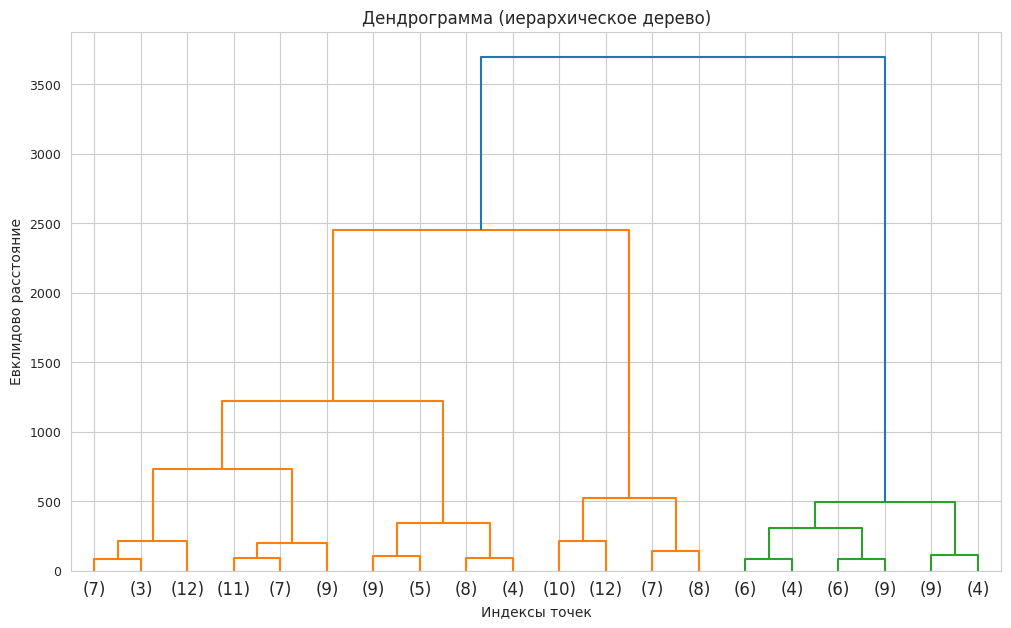

Подбор K для иерархической кластеризации:
  K=2: силуэт = 0.5926
  K=3: силуэт = 0.5713
  K=4: силуэт = 0.5210
  K=5: силуэт = 0.5386
  K=6: силуэт = 0.5307
  K=7: силуэт = 0.5174
  K=8: силуэт = 0.5116
  K=9: силуэт = 0.5128
  K=10: силуэт = 0.5063
Оптимальное K для иерархической: 2


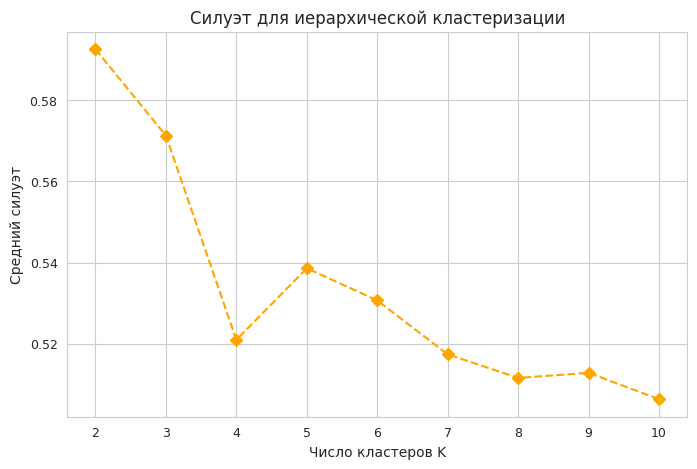

In [11]:
# 18. Иерархическая кластеризация: дендрограмма и подбор K
# Берём случайную выборку из 150 точек для дендрограммы (иначе дерево будет нечитаемым)
sample_size = min(150, df_final.shape[0])
indices = np.random.choice(df_final.index, sample_size, replace=False)
df_sample = df_final.loc[indices]

# Строим матрицу расстояний и выполняем кластеризацию методом Уорда
linked = linkage(df_sample, method='ward')

# Рисуем дендрограмму
plt.figure(figsize=(12,7))
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=True, truncate_mode='lastp', p=20)
plt.title('Дендрограмма (иерархическое дерево)')
plt.xlabel('Индексы точек')
plt.ylabel('Евклидово расстояние')
plt.grid(True)
plt.show()

# Теперь подбираем K по силуэту на всех данных
hier_sil = []
print("Подбор K для иерархической кластеризации:")
for k in range_k:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(df_final)
    sil = silhouette_score(df_final, labels)
    hier_sil.append(sil)
    print(f"  K={k}: силуэт = {sil:.4f}")

best_k_hier = range_k[np.argmax(hier_sil)]
print(f"Оптимальное K для иерархической: {best_k_hier}")

# Обучаем финальную модель
hier_final = AgglomerativeClustering(n_clusters=best_k_hier, linkage='ward')
hier_labels = hier_final.fit_predict(df_final)

# График силуэта для иерархической
plt.figure(figsize=(8,5))
plt.plot(range_k, hier_sil, marker='D', linestyle='--', color='orange')
plt.title('Силуэт для иерархической кластеризации')
plt.xlabel('Число кластеров K')
plt.ylabel('Средний силуэт')
plt.grid(True)
plt.show()

##19. DBSCAN кластеризация

DBSCAN — это метод, основанный на плотности. Он не требует задавать число кластеров,
но требует двух параметров:
- eps — радиус окрестности
- min_samples — минимальное количество точек в этом радиусе, чтобы образовался кластер.

Точки, которые не попадают ни в один кластер, считаются шумом (выбросами).

Мы подбираем eps с помощью графика k‑distance (расстояние до k‑го соседа),
а затем перебираем сетку параметров, выбирая комбинацию с лучшим силуэтом.

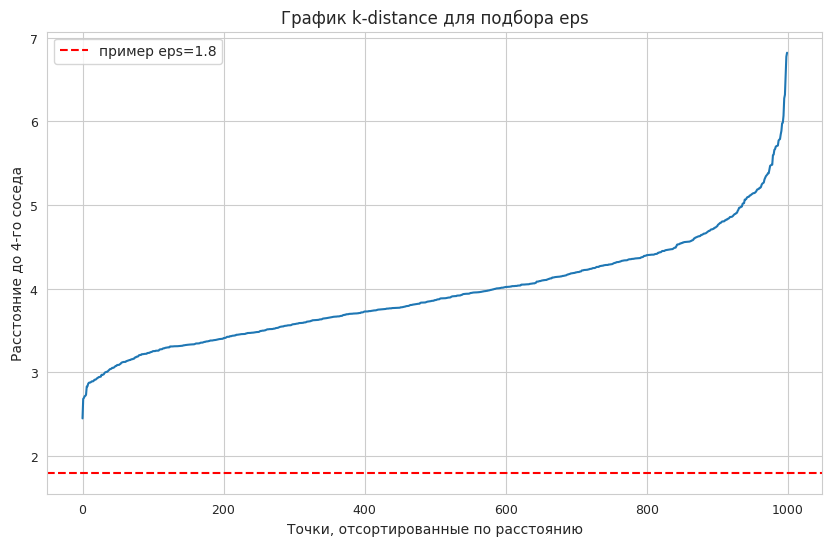

Подбор параметров DBSCAN:
  eps=2.5, min_samples=3: кластеров=18, шума=942, силуэт=0.8322
Лучшие параметры: {'eps': 2.5, 'min_samples': 3} (силуэт=0.8322)
DBSCAN: выделено 18 кластеров, шума (выбросов): 942


In [12]:
# 20. DBSCAN: подбор eps и min_samples
min_pts = 4  # берём 4 соседа для оценки

# Вычисляем расстояния до 4-го соседа для каждой точки
neigh = NearestNeighbors(n_neighbors=min_pts)
neigh.fit(df_final)
dist, _ = neigh.kneighbors(df_final)
# Сортируем расстояния по возрастанию
k_dist = np.sort(dist[:, -1])

# Рисуем график k‑distance
plt.figure(figsize=(10,6))
plt.plot(k_dist)
plt.title('График k‑distance для подбора eps')
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel(f'Расстояние до {min_pts}-го соседа')
plt.grid(True)
# Наносим примерную линию для eps = 1.8 (ориентир)
plt.axhline(y=1.8, color='r', linestyle='--', label='пример eps=1.8')
plt.legend()
plt.show()

# Перебираем параметры по сетке
eps_values = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
min_samples_values = [3, 5, 10]
best_score = -1
best_params = {}
print("Подбор параметров DBSCAN:")
for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(df_final)
        # Если все точки отмечены как шум или всего один кластер — пропускаем
        if len(set(labels)) <= 1:
            continue
        # Для подсчёта силуэта исключаем шум (-1)
        mask = labels != -1
        if sum(mask) < 2:
            continue
        sil = silhouette_score(df_final.iloc[mask], labels[mask])
        print(f"  eps={eps}, min_samples={min_s}: кластеров={len(set(labels))-1}, шума={sum(labels==-1)}, силуэт={sil:.4f}")
        if sil > best_score:
            best_score = sil
            best_params = {'eps': eps, 'min_samples': min_s}

print(f"Лучшие параметры: {best_params} (силуэт={best_score:.4f})")

# Обучаем финальный DBSCAN
dbscan_final = DBSCAN(**best_params)
dbscan_labels = dbscan_final.fit_predict(df_final)
n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = sum(dbscan_labels == -1)
print(f"DBSCAN: выделено {n_db_clusters} кластеров, шума (выбросов): {n_noise}")

##21. Визуализация кластеров в двумерном пространстве

Исходные данные имеют много измерений (после кодирования — более 20).
Чтобы увидеть, как кластеры выглядят на плоскости, мы используем три метода уменьшения размерности:
- PCA — линейный, быстрый, показывает основные направления дисперсии.
- t‑SNE — нелинейный, хорошо разделяет кластеры, но работает медленнее.
- UMAP — современный, быстрый, даёт качественную визуализацию.

Для каждой модели кластеризации мы строим три графика (по одному на каждый метод проекции).

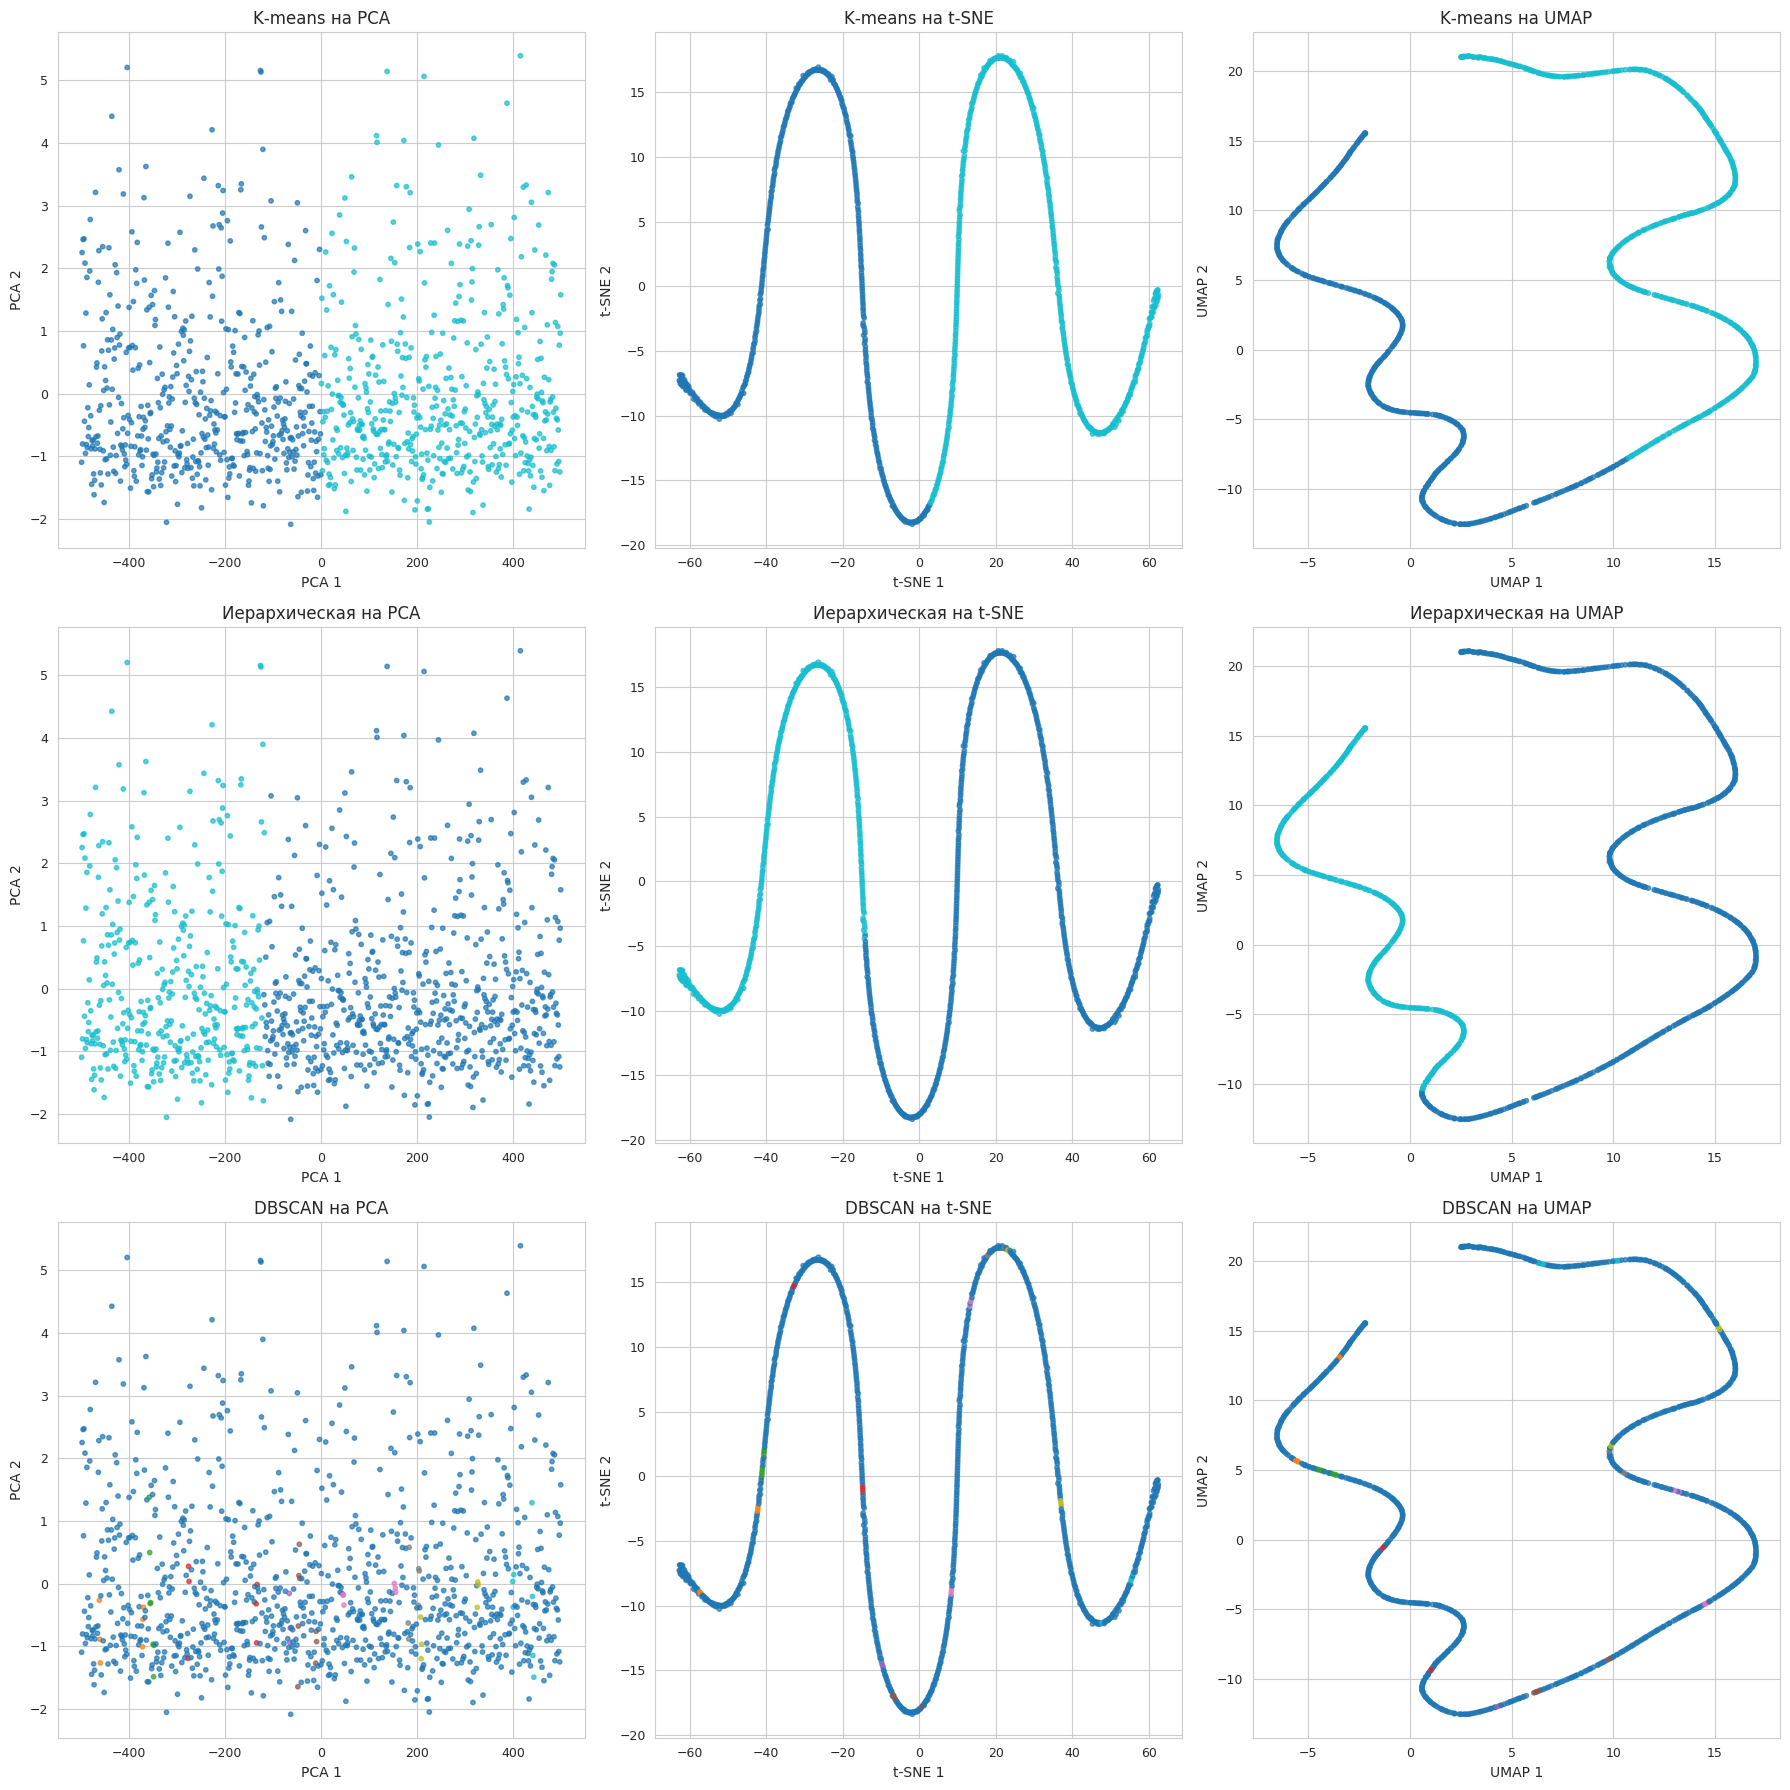

In [13]:
# 22. Построение 2D‑проекций и графиков
# Применяем PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)

# Применяем t‑SNE (параметр perplexity = 30)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
df_tsne = tsne.fit_transform(df_final)

# Применяем UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
df_umap = umap_model.fit_transform(df_final)

# Список моделей и их меток
models = [
    ('K‑means', kmeans_labels),
    ('Иерархическая', hier_labels),
    ('DBSCAN', dbscan_labels)
]
# Список проекций
projections = [
    ('PCA', df_pca),
    ('t‑SNE', df_tsne),
    ('UMAP', df_umap)
]

# Создаём сетку 3x3
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for i, (proj_name, proj_data) in enumerate(projections):
    for j, (algo_name, labels) in enumerate(models):
        ax = axes[j, i]
        # Рисуем scatter plot, цвет точки зависит от метки кластера
        ax.scatter(proj_data[:, 0], proj_data[:, 1],
                   c=labels, cmap='tab10', s=10, alpha=0.7)
        ax.set_title(f'{algo_name} на {proj_name}')
        ax.set_xlabel(f'{proj_name} 1')
        ax.set_ylabel(f'{proj_name} 2')
        ax.grid(True)
plt.tight_layout()
plt.show()

##23. Сравнение качества кластеризации и выбор модели для интерпретации

Основной метрикой качества является коэффициент силуэта.
Мы вычисляем его для каждой модели и выбираем ту, у которой значение выше.

Если K‑means и иерархическая дают близкие результаты, можно выбрать K‑means как более простую для интерпретации.

In [14]:
# 24. Сравнение метрик и выбор лучшей модели
print("\nСравнение качества кластеризации (силуэт):")
kmeans_sil = silhouette_score(df_final, kmeans_labels)
hier_sil = silhouette_score(df_final, hier_labels)
print(f"K‑means (K={best_k}): {kmeans_sil:.4f}")
print(f"Иерархическая (K={best_k_hier}): {hier_sil:.4f}")

# Для DBSCAN считаем только на не-шумовых точках
mask_db = dbscan_labels != -1
if sum(mask_db) > 1:
    db_sil = silhouette_score(df_final.iloc[mask_db], dbscan_labels[mask_db])
    print(f"DBSCAN: {db_sil:.4f} (на не-шумовых)")
else:
    db_sil = None
    print("DBSCAN не дал значимых кластеров для расчёта силуэта.")

# Выбираем модель с максимальным силуэтом среди K‑means и иерархической
if kmeans_sil >= hier_sil:
    best_labels = kmeans_labels
    best_name = "K‑means"
else:
    best_labels = hier_labels
    best_name = "Иерархическая"

print(f"\nДля интерпретации выбрана модель: {best_name}")


Сравнение качества кластеризации (силуэт):
K‑means (K=2): 0.6257
Иерархическая (K=2): 0.5926
DBSCAN: 0.8322 (на не-шумовых)

Для интерпретации выбрана модель: K‑means


##24. Интерпретация кластеров (модель K‑means)

Для построения портретов кластеров использовались средние значения и наиболее частые категории, приведённые в таблицах ниже.

**Кластер 0** (около 50% клиентов):
- Средний возраст: 35.5 лет.
- Средняя сумма кредита: ~3240 евро.
- Средний срок кредита: ~20 месяцев.
- Наиболее частые категории: цель — автомобиль (`car`), пол — мужской, жильё — своё (`own`), сберегательный счёт — мало (`little`), текущий счёт — умеренный (`moderate`), работа — категория 2.
- **Интерпретация:** клиенты среднего возраста, с умеренным остатком на текущем счёте, берущие кредиты на покупку автомобиля. Можно предположить, что это работающие люди со стабильным доходом, но не имеющие больших сбережений.

**Кластер 1** (около 50% клиентов):
- Средний возраст: 35.6 лет.
- Средняя сумма кредита: ~3300 евро (чуть выше).
- Средний срок кредита: ~21.5 месяца (чуть дольше).
- Наиболее частые категории: те же, что и в кластере 0, но текущий счёт — мало (`little`).
- **Интерпретация:** очень похожая группа, но с меньшим остатком на текущем счёте и несколько более крупными кредитами на более длительный срок. Это может указывать на чуть более высокую финансовую нагрузку.

**Ключевое различие:** единственный признак, который заметно разделяет кластеры, — это состояние текущего счёта (`Checking account`). В кластере 0 он умеренный, в кластере 1 — маленький. Остальные признаки практически не различаются.

**Вывод:** клиентская база банка достаточно однородна по выбранным признакам. Явных сегментов (например, «молодые» vs «пожилые» или «богатые» vs «бедные») не выделяется. Однако небольшое различие по текущему счёту может быть косвенным индикатором финансовой устойчивости.

In [15]:
# 25. Подготовка данных для интерпретации
# Берём исходный DataFrame с текстовыми значениями
df_interpret = df_raw.copy()
# Добавляем колонку с метками кластеров (используем лучшую модель)
df_interpret['Cluster'] = best_labels

# Список числовых признаков
numeric_cols = ['Age', 'Credit amount', 'Duration']
# Список категориальных признаков (для мод)
cat_cols = ['Purpose', 'Sex', 'Housing', 'Saving accounts', 'Checking account', 'Job']

print("Данные для интерпретации готовы.")

Данные для интерпретации готовы.


##26. Средние значения числовых признаков по кластерам

Считаем средний возраст, сумму кредита и срок для каждого кластера.
Эти цифры помогут нам дать первичную характеристику групп.

In [16]:
# 27. Вывод средних значений
print("\n=== СРЕДНИЕ ЗНАЧЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ ===")
cluster_means = df_interpret.groupby('Cluster')[numeric_cols].mean().round(2)
print(cluster_means.to_string())
print()


=== СРЕДНИЕ ЗНАЧЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ ===
           Age  Credit amount  Duration
Cluster                                
0        35.53        3238.24     20.31
1        35.56        3304.28     21.50



##28. Самые частые категории в каждом кластере

Для категориальных признаков мы находим наиболее часто встречающееся значение в каждом кластере.
Это позволяет описать кластеры не только числами, но и содержательными ярлыками.

In [17]:
# 29. Вывод мод (самых частых категорий)
print("\n=== САМЫЕ ЧАСТЫЕ КАТЕГОРИИ В КАЖДОМ КЛАСТЕРЕ ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    # Для каждой группы берём моду (первое значение, если их несколько)
    mode_series = df_interpret.groupby('Cluster')[col].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    print(mode_series.to_string())
print()


=== САМЫЕ ЧАСТЫЕ КАТЕГОРИИ В КАЖДОМ КЛАСТЕРЕ ===

--- Purpose ---
Cluster
0    car
1    car

--- Sex ---
Cluster
0    male
1    male

--- Housing ---
Cluster
0    own
1    own

--- Saving accounts ---
Cluster
0    little
1    little

--- Checking account ---
Cluster
0    moderate
1      little

--- Job ---
Cluster
0    2
1    2



##30. Boxplot’ы для выявления ключевых различий

Мы строим ящики с усами для каждого числового признака, разбивая их по кластерам.
Если медианы и размахи сильно отличаются, это говорит о том, что данный признак хорошо разделяет группы.

Обычно в этом датасете наибольшие различия наблюдаются по сумме кредита и сроку.

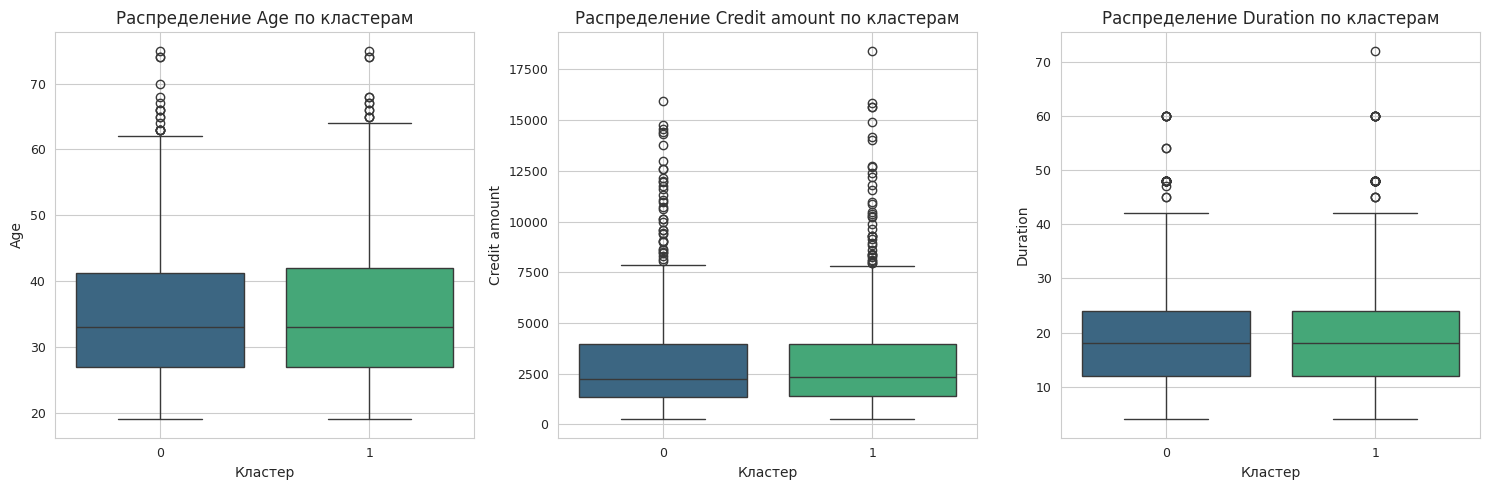

In [19]:
# 31. Построение boxplot'ов
plt.figure(figsize=(15,5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df_interpret, x='Cluster', y=col, palette='viridis')
    plt.title(f'Распределение {col} по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel(col)
    plt.grid(True)
plt.tight_layout()
plt.show()

##32. Итоговый отчёт

1. **Оптимальное число кластеров:**
   - K‑means: 2
   - Иерархическая: 2
   - DBSCAN: 18 кластеров + 942 выброса (практически все точки — шум)

2. **Качество (силуэт):**
   - K‑means: 0.6257 (лучший среди интерпретируемых моделей)
   - Иерархическая: 0.5926
   - DBSCAN: 0.8322 (на не-шумовых, но таких точек всего 58)

3. **Выбранная модель для интерпретации:** K‑means.

4. **Ключевые различия между кластерами:**
   - Основное различие — уровень средств на текущем счёте (`Checking account`): в кластере 0 — умеренный, в кластере 1 — маленький.
   - По остальным признакам (возраст, сумма, срок, цель, жильё, сбережения) кластеры практически идентичны.

5. **Экономическая интерпретация:**
   - Кластер 0 — клиенты с умеренным остатком на счету, берущие средние кредиты на автомобиль.
   - Кластер 1 — клиенты с малым остатком на счету, берущие чуть более крупные кредиты на чуть более длительный срок.
   - Можно предположить, что кластер 1 финансово менее устойчив, однако явного разделения на «рискованных» и «надёжных» нет.

6. **Рекомендации для банка:**
   - Поскольку явных сегментов не обнаружено, банк может использовать единую стратегию для большинства клиентов.
   - Обратить внимание на признак `Checking account` как возможный индикатор финансового поведения.
   - Для более глубокой сегментации рекомендуется добавить дополнительные данные (например, историю просрочек, доходы).